REGRESSION ON OList-Ecommerce.csv

Part A – Dataset & Exploratory Data Analysis
Load and inspect the Olist e-commerce dataset.
Understand the dataset structure, features, and data types.
Generate statistical summaries for numerical features.
Identify and analyze missing values and duplicate records.
Select price as the regression target variable.
Analyze the distribution of the target variable.
Visualize the distributions of numerical and categorical features.
Perform correlation analysis among numerical features.
Analyze the relationship between important numerical features and price using scatter plots.
Identify patterns, relationships, skewness, and potential outliers.
Summarize the major EDA insights to guide further preprocessing and modeling.

Part B – Data Preprocessing & Feature Engineering
Remove duplicate records from the dataset.
Handle records with missing target (price) values.
Convert the order purchase timestamp into meaningful date/time features.
Create features such as year, month, day, hour, and day of the week.
Detect potential outliers using the IQR method.
Retain legitimate outliers rather than automatically removing them.
Remove irrelevant identifier columns and free-text review columns.
Separate the dataset into features (X) and target (y).
Split the data into 80% training and 20% testing sets.
Handle missing numerical values using median imputation.
Handle missing categorical values using the most frequent value.
Apply One-Hot Encoding to categorical features.
Apply StandardScaler to numerical features.
Ensure preprocessing is performed using the training data to avoid data leakage.
Produce clean, transformed data ready for regression modeling.

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries required for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

# Read the Olist e-commerce dataset
df = pd.read_csv("OList-Ecommerce.csv")

# Display the size of the dataset
print("Dataset loaded successfully!")
print("Number of rows and columns:", df.shape)

Dataset loaded successfully!
Number of rows and columns: (32995, 17)


In [3]:
# ============================================================
# DISPLAY FIRST AND LAST RECORDS
# ============================================================

# Display the first 5 records
print("First 5 records:")
display(df.head())

# Display the last 5 records
print("\nLast 5 records:")
display(df.tail())

First 5 records:


,order_id,customer_id,order_purchase_timestamp,order_status,customer_city,customer_state,product_id,seller_id,price,freight_value,review_score,review_comment_title,review_comment_message,seller_city,seller_state,product_weight_g,product_category_name_english
0,0006ec9db01a64e59a68b2c340bf65a7,5d178120c29c61748ea95bac23cb8f25,2018-07-24 17:04:17,delivered,rio de janeiro,RJ,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,74.0,23.32,5.0,Boa,Excelente serviço de compras on line.,ibitinga,SP,1383,bed_bath_table
1,0009c9a17f916a706d71784483a5d643,8a250edc40ebc5c3940ebc940f16a7eb,2018-04-25 09:10:41,delivered,campinas,SP,3f27ac8e699df3d300ec4a5d8c5cf0b2,fcb5ace8bcc92f75707dc0f01a27d269,639.0,11.34,4.0,NaN,NaN,guarulhos,SP,200,consoles_games
2,000aed2e25dbad2f9ddb70584c5a2ded,fff5169e583fd07fac9fec88962f189d,2018-05-11 20:33:38,delivered,santa barbara d'oeste,SP,4fa33915031a8cde03dd0d3e8fb27f01,fe2032dab1a61af8794248c8196565c9,144.0,8.77,NaN,NaN,NaN,campinas,SP,468,perfumery
3,002175704e8b209f61b9ad5cfd92b60e,a562db3c7cb9a68947debd30879b491e,2018-04-22 12:13:25,delivered,araraquara,SP,e6b6e13cf71449a457269f425b89dc74,b2ba3715d723d245138f291a6fe42594,109.9,13.21,4.0,Recomendo,Produto como descrito. Mas não gostei pq o som...,sao paulo,SP,588,audio
4,930fff097a9427c8a9a70559aa36fa76,dc56b538928bb9f7212da239e24cda3d,2018-08-22 11:52:54,delivered,maua,SP,5d6bea33648f018dbb563f3a2fab09f3,1025f0e2d44d7041d6cf58b6550e0bfa,159.8,16.42,2.0,NaN,Produto lindo! De ótima qualidade,sao paulo,SP,4000,furniture_decor



Last 5 records:


,order_id,customer_id,order_purchase_timestamp,order_status,customer_city,customer_state,product_id,seller_id,price,freight_value,review_score,review_comment_title,review_comment_message,seller_city,seller_state,product_weight_g,product_category_name_english
32990,928e8e158d1096bf9bad69d9e927b6b0,925ddf3482c150d9e469c4b47d52e1c2,2018-05-22 20:21:55,delivered,caruaru,PE,332842d24e84234cd91299a225de76ab,634964b17796e64304cadf1ad3050fb7,399.00,59.34,4.0,10,NaN,rio de janeiro,RJ,1750,watches_gifts
32991,92907309dff7adcd19bbbb29d5fda792,5f5babb717b93691c4757d4bfc1293a2,2018-08-18 22:38:03,delivered,sao bernardo do campo,SP,90dbd461e405599ef4d208e19e472125,c3aad7dc65449ae90a5e9c3c6c1e78e0,90.00,17.76,4.0,NaN,NaN,auriflama/sp,SP,4100,party_supplies
32992,92b7ad3b562646f9112aa21df37f790b,c9da69edb9b3c5e7b8074ac4ea9b2244,2018-08-20 19:02:22,delivered,itapema,SC,6f4f2bb136fd2d8e8229355d8fec6b67,06e5eefc71ec47ae763c5c6f8db7064f,379.94,20.76,4.0,Estou configurando nest,NaN,porto alegre,RS,350,construction_tools_safety
32993,92d1d8203d3deb0f8b536250763d8bca,b74f0b9f1edb86da06a9c032d80fd1e8,2018-08-11 16:39:54,delivered,osasco,SP,23cb417be12fb9557a815962aedefff5,bb135baca94c82fcb731335ad5b04a03,45.00,7.58,4.0,NaN,NaN,sao paulo,SP,200,housewares
32994,92d82a97b257e7e81b567f8ceb8b89a3,fd65e5fe0237e5d9d5a346ed57652831,2018-06-13 09:18:06,delivered,uberlandia,MG,d63c1011f49d98b976c352955b1c4bea,cc419e0650a3c5ba77189a1882b7556a,59.99,23.22,4.0,Top,Ótimo produto,santo andre,SP,950,health_beauty


In [4]:
# ============================================================
# DATASET INFORMATION
# ============================================================

# Display information about:
# - Number of entries
# - Column names
# - Non-null values
# - Data types
# - Memory usage

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32995 entries, 0 to 32994
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       32995 non-null  str    
 1   customer_id                    32995 non-null  str    
 2   order_purchase_timestamp       32995 non-null  str    
 3   order_status                   32995 non-null  str    
 4   customer_city                  32995 non-null  str    
 5   customer_state                 32995 non-null  str    
 6   product_id                     32995 non-null  str    
 7   seller_id                      32995 non-null  str    
 8   price                          32995 non-null  float64
 9   freight_value                  32995 non-null  float64
 10  review_score                   23435 non-null  float64
 11  review_comment_title           9090 non-null   str    
 12  review_comment_message         9589 non-null   str    
 1

In [5]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================

# Generate descriptive statistics for numerical columns
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
price,32995.0,123.072503,194.338391,0.85,39.99,77.9,134.99,6729.00
freight_value,32995.0,21.061500,18.291288,0.00,12.79,18.2,22.98,375.28
review_score,23435.0,3.409473,1.301759,1.00,2.00,3.0,5.00,5.00
product_weight_g,32995.0,1925.218154,3454.403550,0.00,264.00,600.0,1683.00,30000.00


In [6]:
# ============================================================
# MISSING VALUE AUDIT
# ============================================================

# Calculate missing-value count and percentage
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

# Display only columns containing missing values
display(
    missing_summary[
        missing_summary["Missing Count"] > 0
    ].sort_values(
        by="Missing Count",
        ascending=False
    )
)

,Missing Count,Missing Percentage
review_comment_title,23905,72.45
review_comment_message,23406,70.94
review_score,9560,28.97


In [7]:
# ============================================================
# DUPLICATE RECORD ANALYSIS
# ============================================================

# Count completely duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Calculate duplicate percentage
duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(
    "Duplicate percentage:",
    round(duplicate_percentage, 2),
    "%"
)

Number of duplicate rows: 2951
Duplicate percentage: 8.94 %


In [8]:
# ============================================================
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

# Numerical columns
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Categorical/object columns
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numerical_columns)

print("\nCategorical features:")
print(categorical_columns)

Numerical features:
['price', 'freight_value', 'review_score', 'product_weight_g']

Categorical features:
['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status', 'customer_city', 'customer_state', 'product_id', 'seller_id', 'review_comment_title', 'review_comment_message', 'seller_city', 'seller_state', 'product_category_name_english']


In [9]:
# ============================================================
# DEFINE REGRESSION TARGET
# ============================================================

# Price is selected as the target variable because
# it is a continuous numerical variable.
TARGET = "price"

print("Regression target:", TARGET)

# Display target statistics
display(df[TARGET].describe())

# Check whether the target contains missing values
print(
    "Missing values in target:",
    df[TARGET].isnull().sum()
)

Regression target: price


count    32995.000000
mean       123.072503
std        194.338391
min          0.850000
25%         39.990000
50%         77.900000
75%        134.990000
max       6729.000000
Name: price, dtype: float64

Missing values in target: 0


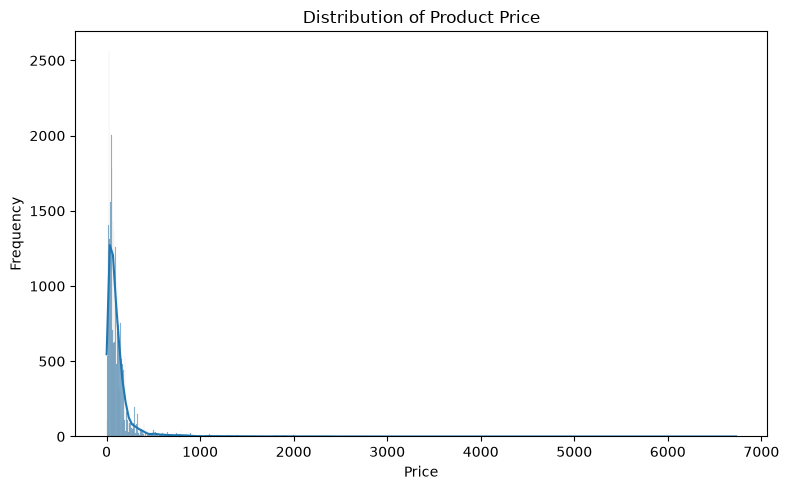

In [10]:
# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

# Plot distribution of product prices
sns.histplot(
    df[TARGET].dropna(),
    kde=True
)

plt.title("Distribution of Product Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

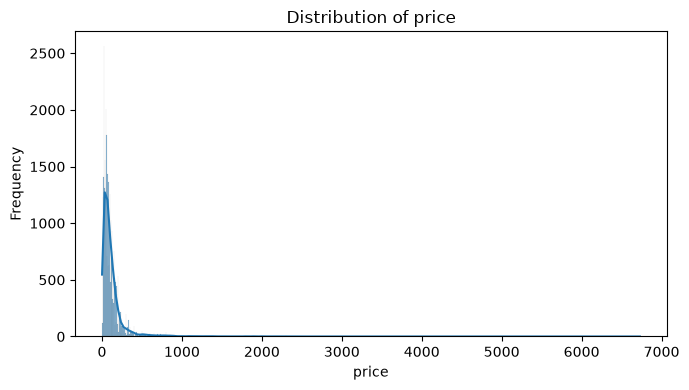

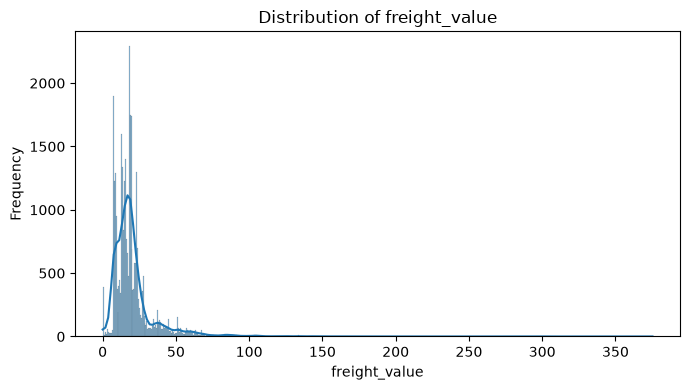

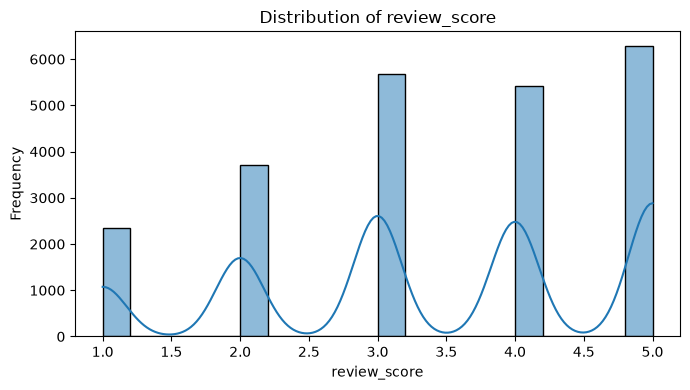

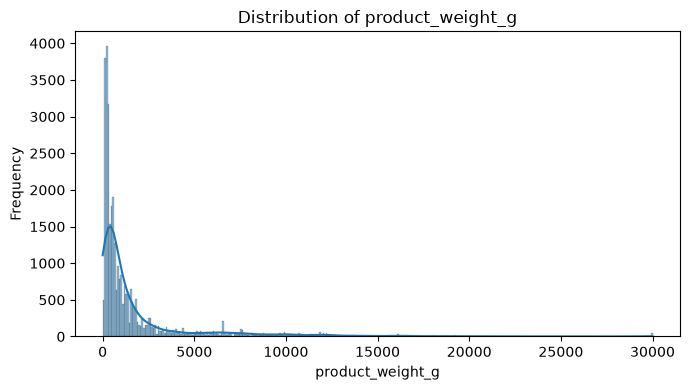

In [11]:
# ============================================================
# DISTRIBUTION OF NUMERICAL FEATURES
# ============================================================

# Plot the distribution of every numerical feature
for column in numerical_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[column].dropna(),
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

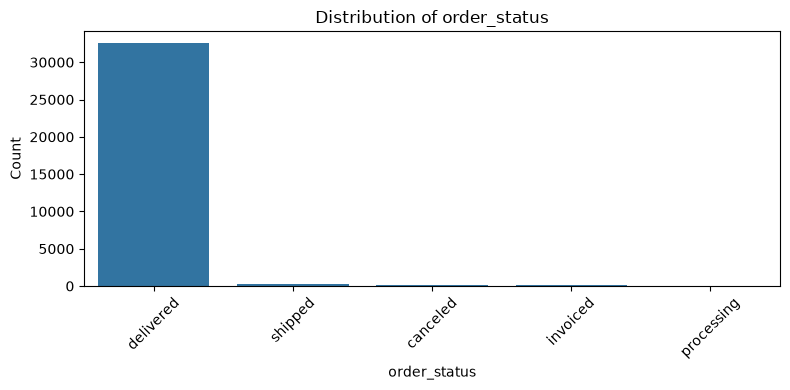

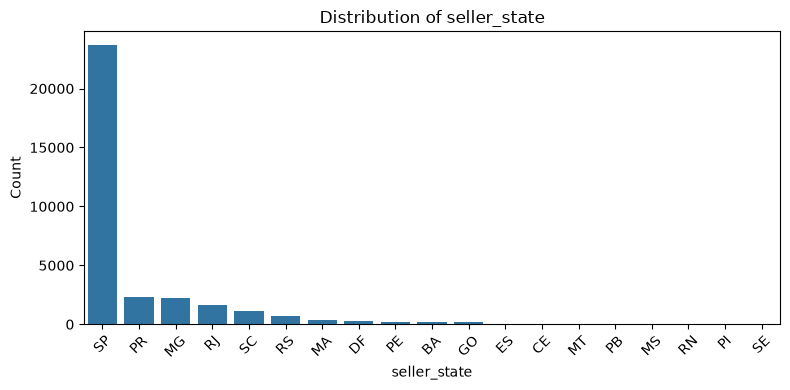

In [12]:
# ============================================================
# DISTRIBUTION OF CATEGORICAL FEATURES
# ============================================================

# Count plots are used for categorical variables.
# Very high-cardinality columns are skipped because
# plotting thousands of categories would not be meaningful.

for column in categorical_columns:

    if df[column].nunique() <= 20:

        plt.figure(figsize=(8, 4))

        sns.countplot(
            data=df,
            x=column,
            order=df[column].value_counts().index
        )

        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Count")

        # Rotate labels for better readability
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

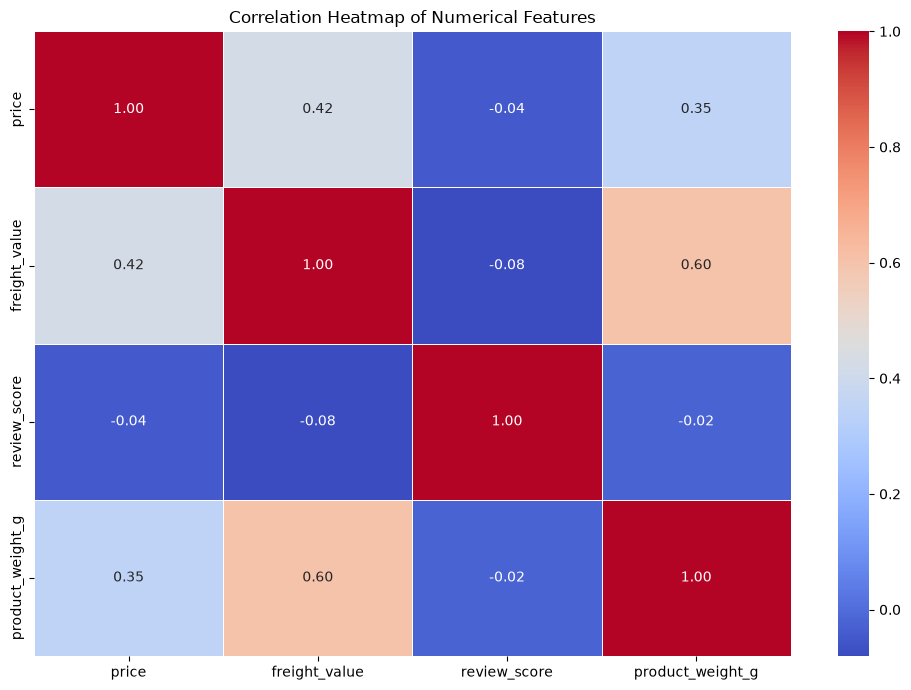

In [13]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

# Select only numerical columns because correlation
# is calculated between numerical variables.
correlation_matrix = df[
    numerical_columns
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# FIND FEATURES MOST CORRELATED WITH PRICE
# ============================================================

# Calculate correlation of every numerical feature with price
target_correlation = (
    correlation_matrix["price"]
    .drop("price")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("Correlation of numerical features with price:")
display(target_correlation)

# Select the two features with the strongest absolute correlation
top_features = target_correlation.abs().head(2).index

print("Features selected for scatter plots:")
print(top_features.tolist())

Correlation of numerical features with price:


freight_value       0.421029
product_weight_g    0.346716
review_score       -0.043951
Name: price, dtype: float64

Features selected for scatter plots:
['freight_value', 'product_weight_g']


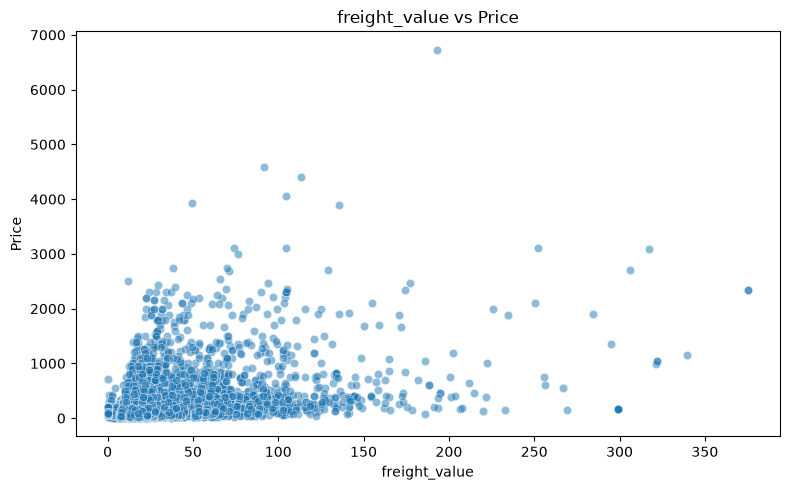

In [15]:
# ============================================================
# SCATTER PLOT 1
# ============================================================

feature1 = top_features[0]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x=feature1,
    y="price",
    alpha=0.5
)

plt.title(f"{feature1} vs Price")
plt.xlabel(feature1)
plt.ylabel("Price")

plt.tight_layout()
plt.show()

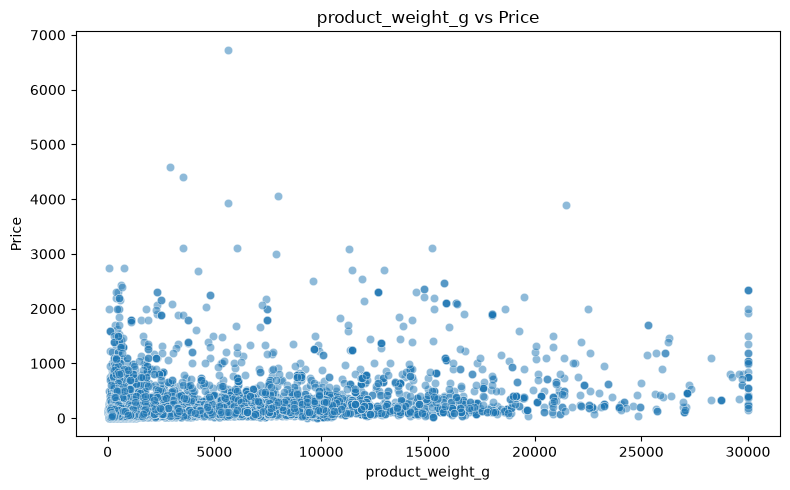

In [16]:
# ============================================================
# SCATTER PLOT 2
# ============================================================

feature2 = top_features[1]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x=feature2,
    y="price",
    alpha=0.5
)

plt.title(f"{feature2} vs Price")
plt.xlabel(feature2)
plt.ylabel("Price")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# REMOVE DUPLICATE RECORDS
# ============================================================

print(
    "Rows before removing duplicates:",
    len(df)
)

# Remove completely duplicated rows
df = df.drop_duplicates().reset_index(drop=True)

print(
    "Rows after removing duplicates:",
    len(df)
)

Rows before removing duplicates: 32995
Rows after removing duplicates: 30044


In [18]:
# ============================================================
# CONVERT TIMESTAMP TO DATETIME
# ============================================================

# Convert order purchase timestamp from string
# to pandas datetime format.
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

print(
    "Timestamp converted successfully."
)

Timestamp converted successfully.


In [19]:
# ============================================================
# FEATURE ENGINEERING FROM ORDER TIMESTAMP
# ============================================================

# Extract year
df["purchase_year"] = (
    df["order_purchase_timestamp"].dt.year
)

# Extract month
df["purchase_month"] = (
    df["order_purchase_timestamp"].dt.month
)

# Extract day
df["purchase_day"] = (
    df["order_purchase_timestamp"].dt.day
)

# Extract hour
df["purchase_hour"] = (
    df["order_purchase_timestamp"].dt.hour
)

# Extract day of week
# Monday = 0 and Sunday = 6
df["purchase_dayofweek"] = (
    df["order_purchase_timestamp"].dt.dayofweek
)

print("Engineered features created successfully.")

Engineered features created successfully.


In [20]:
# ============================================================
# OUTLIER DETECTION USING IQR METHOD
# ============================================================

# Get numerical columns after feature engineering
numeric_cols = df.select_dtypes(
    include=np.number
).columns

outlier_summary = []

for column in numeric_cols:

    # Calculate first quartile
    Q1 = df[column].quantile(0.25)

    # Calculate third quartile
    Q3 = df[column].quantile(0.75)

    # Calculate Interquartile Range
    IQR = Q3 - Q1

    # Calculate lower and upper limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count observations outside the limits
    outlier_count = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ][column].count()

    outlier_summary.append([
        column,
        outlier_count,
        round(
            outlier_count / len(df) * 100,
            2
        )
    ])

# Convert results into a DataFrame
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Outlier Count",
        "Outlier Percentage"
    ]
)

display(
    outlier_df.sort_values(
        by="Outlier Count",
        ascending=False
    )
)

,Feature,Outlier Count,Outlier Percentage
3,product_weight_g,4045,13.46
1,freight_value,2960,9.85
0,price,2301,7.66
2,review_score,0,0.00
4,purchase_year,0,0.00
5,purchase_month,0,0.00
6,purchase_day,0,0.00
7,purchase_hour,0,0.00
8,purchase_dayofweek,0,0.00


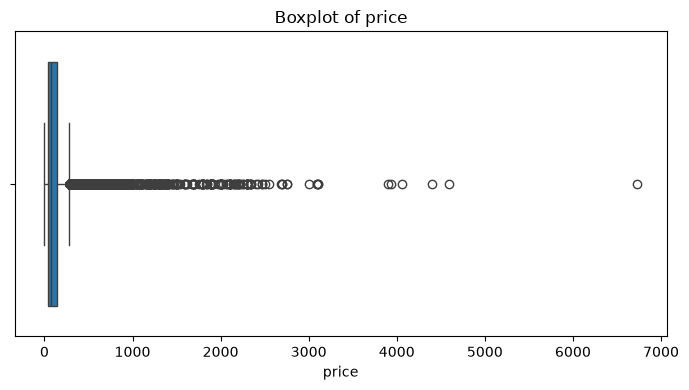

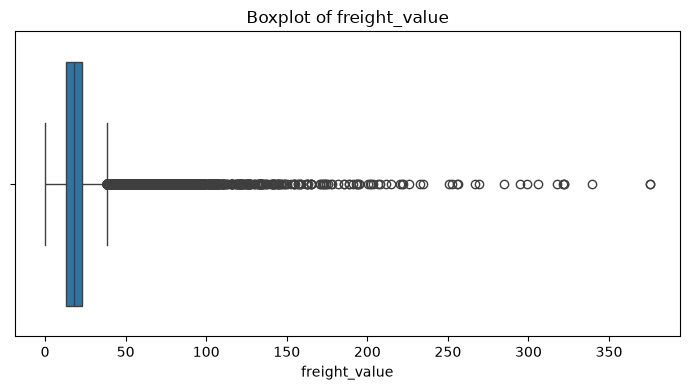

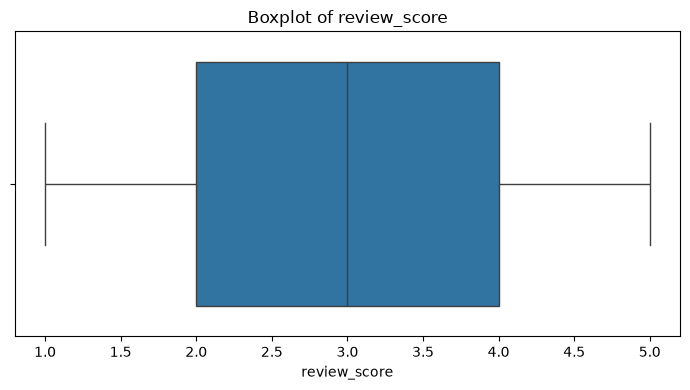

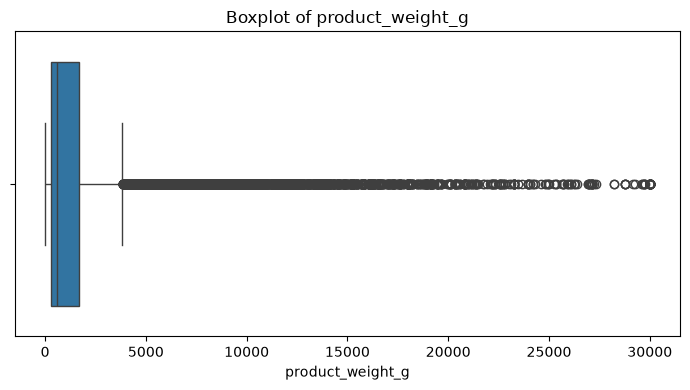

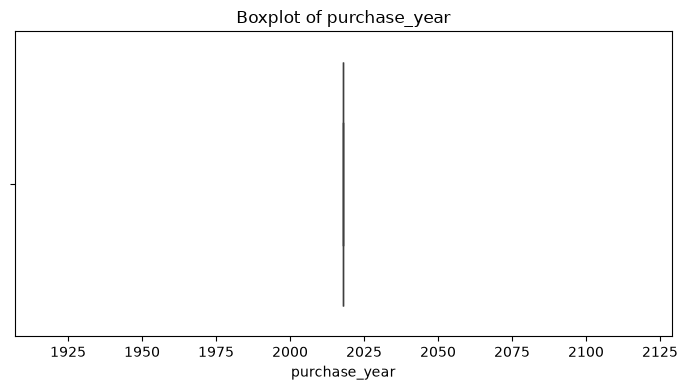

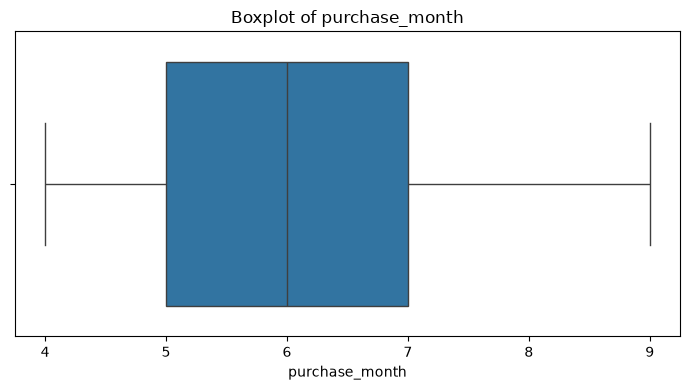

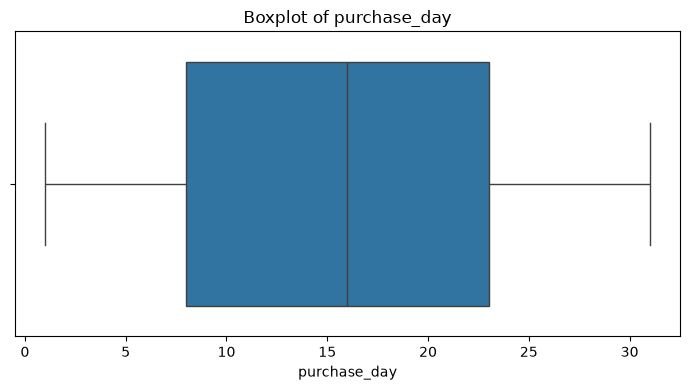

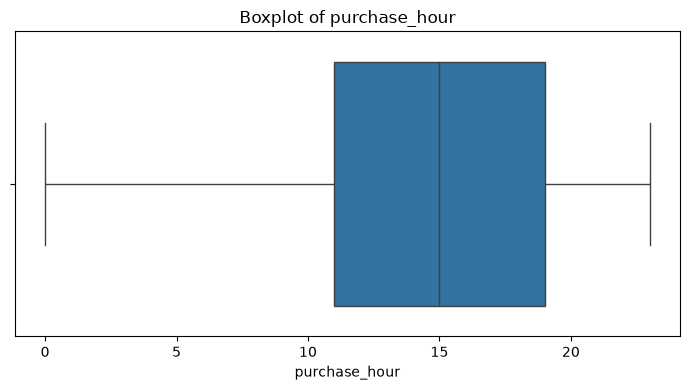

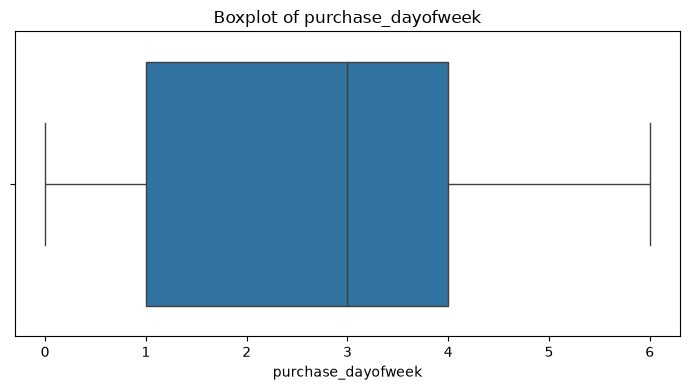

In [21]:
# ============================================================
# BOXPLOTS FOR OUTLIER VISUALIZATION
# ============================================================

for column in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [22]:
# ============================================================
# SEPARATE FEATURES (X) AND TARGET (y)
# ============================================================

# The target variable is price.
TARGET = "price"

# X contains all predictor variables
X = df.drop(columns=[TARGET])

# y contains the target variable
y = df[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (30044, 21)
Target shape: (30044,)


In [23]:
# ============================================================
# REMOVE IDENTIFIER AND FREE-TEXT COLUMNS
# ============================================================

columns_to_drop = [
    "order_id",
    "customer_id",
    "product_id",
    "seller_id",
    "review_comment_title",
    "review_comment_message",
    "order_purchase_timestamp"
]

# Remove columns that are not being used
# in this standard regression pipeline.
X = X.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Remaining features:")
print(X.columns.tolist())

Remaining features:
['order_status', 'customer_city', 'customer_state', 'freight_value', 'review_score', 'seller_city', 'seller_state', 'product_weight_g', 'product_category_name_english', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek']


In [24]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

# Split the data into:
# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (24035, 14)
Testing feature shape: (6009, 14)
Training target shape: (24035,)
Testing target shape: (6009,)


In [25]:
# ============================================================
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

# Numerical features
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

# Categorical features
categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# ============================================================
# NUMERICAL PREPROCESSING
# ============================================================

# Missing numerical values are replaced with the median.
# Median is less affected by extreme values than mean.

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        # Standardize numerical features
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# CATEGORICAL PREPROCESSING
# ============================================================

# Missing categorical values are replaced with
# the most frequently occurring category.

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        # Convert categorical values into binary columns
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

Numerical features:
['freight_value', 'review_score', 'product_weight_g', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek']

Categorical features:
['order_status', 'customer_city', 'customer_state', 'seller_city', 'seller_state', 'product_category_name_english']


In [26]:
# ============================================================
# COMBINE NUMERICAL AND CATEGORICAL PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",numeric_transformer,numeric_features
        ),

        (
            "categorical",categorical_transformer,categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [27]:
# ============================================================
# APPLY PREPROCESSING
# ============================================================

# FIT and TRANSFORM only the training data.
# The imputer, scaler and encoder learn their parameters
# only from the training set.

X_train_processed = preprocessor.fit_transform(
    X_train
)

# Transform the test data using the parameters
# learned from the training data.
X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Processed training data shape:",
    X_train_processed.shape
)

print(
    "Processed testing data shape:",
    X_test_processed.shape
)

Processed training data shape: (24035, 2866)
Processed testing data shape: (6009, 2866)
